**HYPOTHESIS H5 — SEASONALITY**

Shark incidents show seasonal patterns, with some months or seasons having higher recorded incident frequencies.

---

***Which seasons show the highest frequency of recorded shark incidents?***

The analysis of the relationship between **seasons and recorded shark incidents** examines whether shark encounters are distributed evenly throughout the year or whether certain seasons show higher incident frequencies.

In [1]:
from google.colab import files

uploaded = files.upload()

Saving GSAF5.xls to GSAF5.xls


In [2]:
import pandas as pd

In [3]:
df = pd.read_excel("GSAF5.xls")
shark_df = pd.read_excel("GSAF5.xls")

In [4]:
display(shark_df)

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Species,Source,pdf,href formula,href,Case Number,Case Number.1,original order,Unnamed: 21,Unnamed: 22
0,23rd June,2026.0,Unprovoked,Bahamas,Staniel Cay,Exhuma Cays,Swimming,Unknown,M,12,...,Unknown,Keith Cowley: Kevin McMurray Trackingsharks.co...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,13th June,2026.0,Unprovoked,USA,Florida,Reservation Way near Indian Pass,Swimming,Keira Ralph,F,17,...,Unknown small shark,Keith Cowley: Simon De Marchi: All things Emer...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,13th June,2026.0,Unprovoked,Australia,NSW,Coogee Beach,Swimming,Leah Stewart,F,35,...,Great White Shark 4m,Simon De Marchi: Andrew Currie: ABC NEWS: 9 Ne...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th June,2026.0,Unprovoked,Galapogos Islands,Santa Fe Island,Mosquera Islet,Snorkeling,Australia Woman,F,?,...,Unknown,Andrew Currie: Facebook: AbsolutCruceros,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th June,2026.0,Unprovoked,USA,Florida,Panama City,Swimming,Unknown,M,20's,...,2.4m (8ft) Bull shark,James Kingsley:Todd Smith: Kevin McMurray Trac...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7098,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,Roebuck Bay,Diving,male,M,NaN,...,NaN,"H. Taunton; N. Bartlett, p. 234",ND-0005-RoebuckBay.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0005,ND.0005,6.0,NaN,NaN
7099,Before 1903,0.0,Unprovoked,AUSTRALIA,Western Australia,NaN,Pearl diving,Ahmun,M,NaN,...,NaN,"H. Taunton; N. Bartlett, pp. 233-234",ND-0004-Ahmun.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0004,ND.0004,5.0,NaN,NaN
7100,1900-1905,0.0,Unprovoked,USA,North Carolina,Ocracoke Inlet,Swimming,Coast Guard personnel,M,NaN,...,NaN,"F. Schwartz, p.23; C. Creswell, GSAF",ND-0003-Ocracoke_1900-1905.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0003,ND.0003,4.0,NaN,NaN
7101,1883-1889,0.0,Unprovoked,PANAMA,NaN,"Panama Bay 8ºN, 79ºW",NaN,Jules Patterson,M,NaN,...,NaN,"The Sun, 10/20/1938",ND-0002-JulesPatterson.pdf,http://sharkattackfile.net/spreadsheets/pdf_di...,http://sharkattackfile.net/spreadsheets/pdf_di...,ND.0002,ND.0002,3.0,NaN,NaN


**Analysis Plan**
  - Extract and standardize the Date/Year information to identify the season of each recorded incident.
	- Clean and standardize relevant date and location fields.
	- Identify the seasons with the highest and lowest numbers of recorded incidents.

**Create a final comparison table including:**

Season
Total incidents
Percentage of total incidents

In [5]:
print("DATE COLUMNS:")
print([c for c in shark_df.columns if "date" in c.lower()])

print("\nYEAR COLUMNS:")
print([c for c in shark_df.columns if "year" in c.lower()])

print("\nTYPE:")
print([c for c in shark_df.columns if any(word in c.lower() for word in ["type"])])

DATE COLUMNS:
['Date']

YEAR COLUMNS:
['Year']

TYPE:
['Type']


In [7]:
display(
    shark_df[
        ["Date", "Year", "Type", "Fatal Y/N"]
    ].head(10)
)

,Date,Year,Type,Fatal Y/N
0,23rd June,2026.0,Unprovoked,N
1,13th June,2026.0,Unprovoked,N
2,13th June,2026.0,Unprovoked,N
3,11th June,2026.0,Unprovoked,N
4,8th June,2026.0,Unprovoked,N
5,6th June,2026.0,Unprovoked,Y
6,5th June,2026.0,Provoked,N
7,1st June,2026.0,Unprovoked,N
8,1st June,2026.0,Unprovoked,N
9,31st May,2026.0,Unprovoked,N


In [12]:
def get_season(month):
    if pd.isna(month):
        return None
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    elif month in [9, 10, 11]:
        return 'Autumn'
    return None

shark_df['Month'] = shark_df['Incident_Date'].dt.month

shark_df['Season'] = shark_df['Month'].apply(get_season)

display(shark_df[['Incident_Date', 'Month', 'Season']].head(10))

,Incident_Date,Month,Season
0,2026-06-23,6.0,Summer
1,2026-06-13,6.0,Summer
2,2026-06-13,6.0,Summer
3,2026-06-11,6.0,Summer
4,2026-06-08,6.0,Summer
5,2026-06-06,6.0,Summer
6,2026-06-05,6.0,Summer
7,2026-06-01,6.0,Summer
8,2026-06-01,6.0,Summer
9,2026-05-31,5.0,Spring


/tmp/ipykernel_696/3976115126.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Season', y='Total incidents', data=season_incidents, palette='viridis')


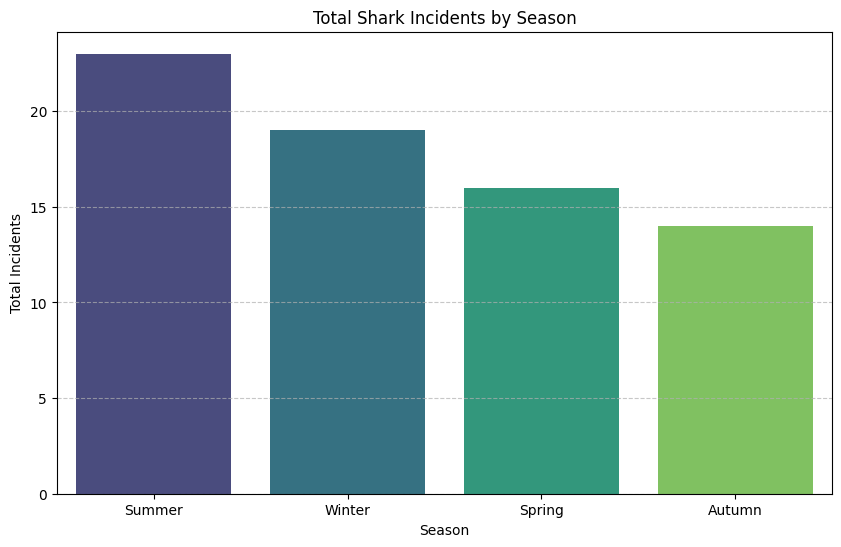

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

season_incidents = shark_df['Season'].value_counts().reset_index()
season_incidents.columns = ['Season', 'Total incidents']

total_incidents_known_season = season_incidents['Total incidents'].sum()
season_incidents['Percentage of total incidents'] = (season_incidents['Total incidents'] / total_incidents_known_season * 100).round(2)

plt.figure(figsize=(10, 6))
sns.barplot(x='Season', y='Total incidents', data=season_incidents, palette='viridis')
plt.title('Total Shark Incidents by Season')
plt.xlabel('Season')
plt.ylabel('Total Incidents')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()